Variant 2

/tmp/ipykernel_6876/2009837918.py:37: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


Shape: (2700, 32738)
Classes: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8'}
00 | train_total=4.7646 | val_total=5.2908 | train_acc=0.1065 | val_acc=0.4259
01 | train_total=3.7474 | val_total=4.7921 | train_acc=0.5778 | val_acc=0.6296
02 | train_total=3.1130 | val_total=4.4705 | train_acc=0.6907 | val_acc=0.6981
03 | train_total=2.6775 | val_total=4.3480 | train_acc=0.7644 | val_acc=0.7463
04 | train_total=2.3339 | val_total=4.2453 | train_acc=0.8218 | val_acc=0.8130
05 | train_total=2.0954 | val_total=4.2063 | train_acc=0.8718 | val_acc=0.8370
06 | train_total=1.9179 | val_total=4.2694 | train_acc=0.8884 | val_acc=0.8611
07 | train_total=1.7467 | val_total=4.2188 | train_acc=0.9051 | val_acc=0.8759
08 | train_total=1.6025 | val_total=4.3537 | train_acc=0.9222 | val_acc=0.8759
09 | train_total=1.5085 | val_total=4.4568 | train_acc=0.9245 | val_acc=0.8722
10 | train_total=1.3710 | val_total=4.2424 | train_acc=0.9329 | val_acc=0.8815
Early stopping


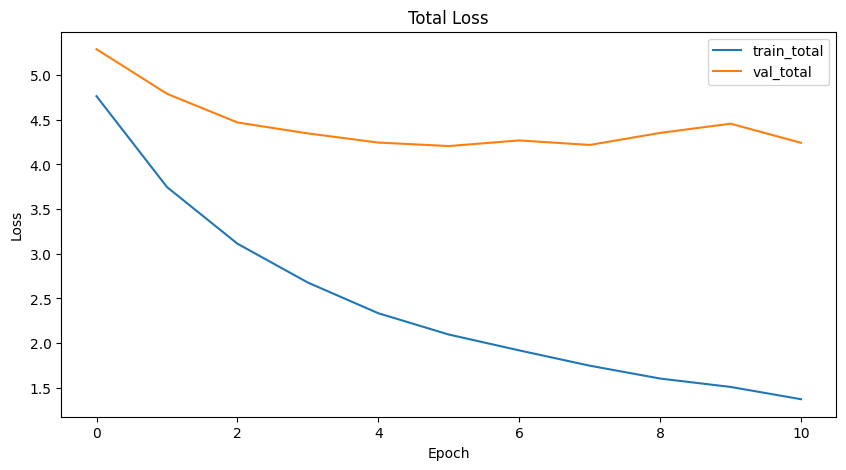

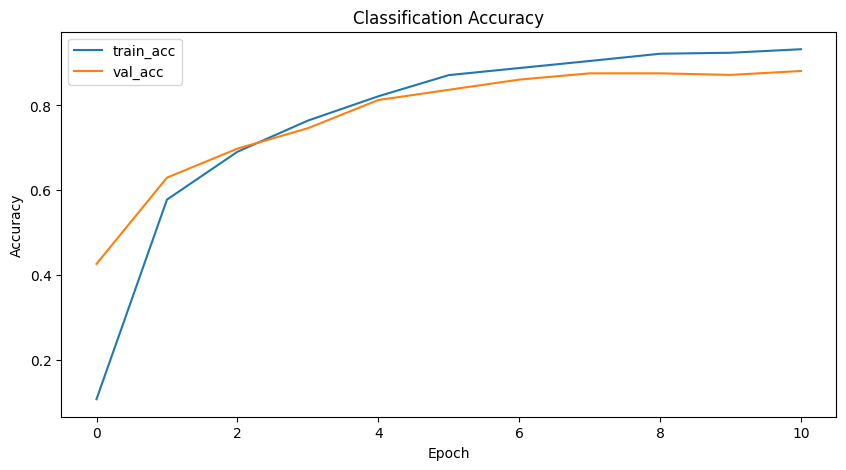

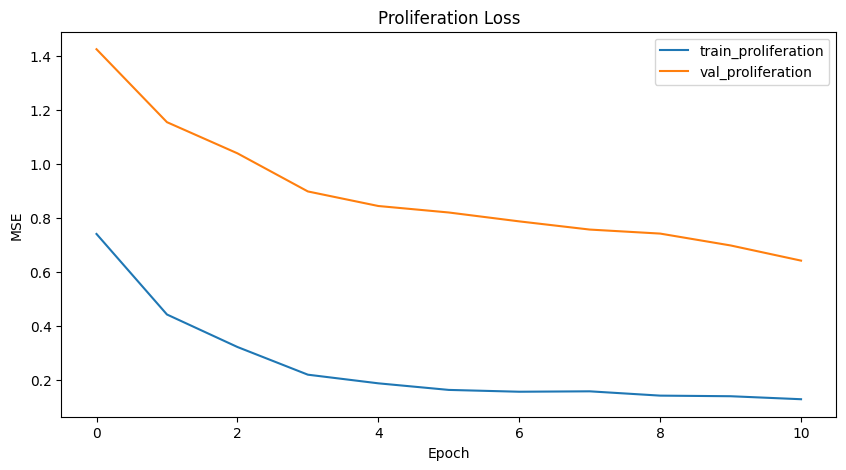

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


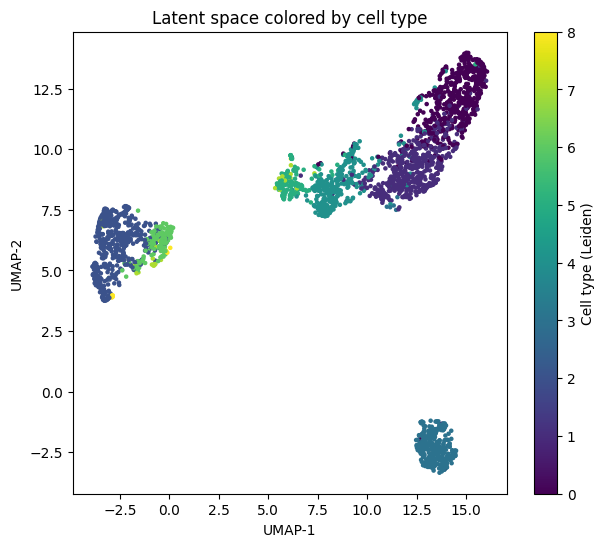

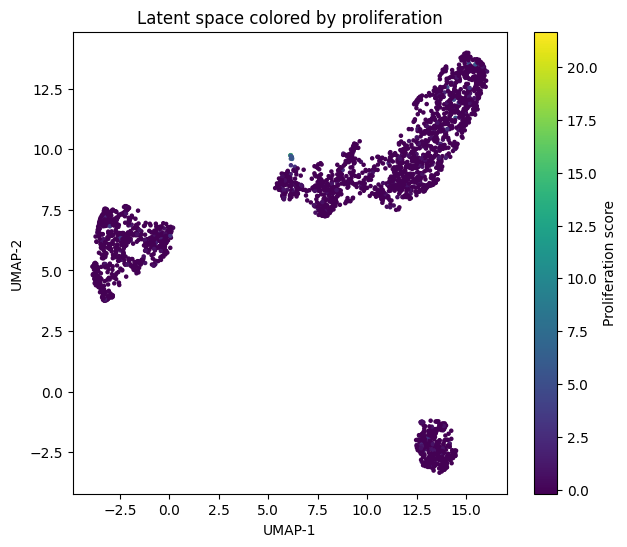

In [ ]:
# ======================
# INSTALL
# ======================
!pip install -q scanpy umap-learn scikit-learn matplotlib torch
!pip install -q python-igraph leidenalg

# ======================
# IMPORTS
# ======================
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import umap
import scanpy as sc

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ======================
# LOAD DATA
# ======================
adata = sc.datasets.pbmc3k()

# clustering
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.leiden(adata, resolution=0.5)

X_raw = adata.X.toarray() if hasattr(adata.X, "toarray") else np.array(adata.X)
genes = adata.var_names.tolist()

print("Shape:", X_raw.shape)

# ======================
# PREPROCESSING
# ======================
X_log = np.log1p(X_raw)
X_scaled = StandardScaler().fit_transform(X_log)

df_genes = pd.DataFrame(X_scaled, columns=genes)

# ======================
# GENE SETS
# ======================
def gene_score(df, geneset):
    present = [g for g in geneset if g in df.columns]
    if len(present) == 0:
        print(f"Warning: no genes found for set: {geneset}")
        return np.zeros(len(df), dtype=np.float32)
    return df[present].mean(axis=1).to_numpy(dtype=np.float32)

stress_genes = ["HIF1A", "HSPA1A", "DNAJB1", "ATF4", "DDIT3"]
immune_genes = ["CD4", "CD8A", "IFNG", "IL2RA", "STAT1", "LST1", "NKG7"]
apoptosis_genes = ["BAX", "CASP3", "TP53", "CASP8", "BCL2"]

# proliferation instead of TERT
proliferation_genes = ["MKI67", "TOP2A", "PCNA", "TYMS", "MCM2", "MCM5", "CDK1", "UBE2C"]

stress = gene_score(df_genes, stress_genes)
immune = gene_score(df_genes, immune_genes)
apoptosis = gene_score(df_genes, apoptosis_genes)
proliferation = gene_score(df_genes, proliferation_genes)

# normalize targets
def norm(x):
    return StandardScaler().fit_transform(x.reshape(-1, 1)).squeeze().astype(np.float32)

y_reg = {
    "stress": norm(stress),
    "immune": norm(immune),
    "apoptosis": norm(apoptosis),
    "proliferation": norm(proliferation),
}

# ======================
# LABEL ENCODER
# ======================
le = LabelEncoder()
cell_type = le.fit_transform(adata.obs["leiden"].astype(str))

print("Classes:", dict(enumerate(le.classes_)))

# ======================
# PCA
# ======================
X_model = PCA(200, random_state=42).fit_transform(X_scaled).astype(np.float32)

# ======================
# SPLIT
# ======================
idx = np.arange(len(X_model))
train_idx, val_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=cell_type
)

X_train, X_val = X_model[train_idx], X_model[val_idx]
y_reg_train = {k: v[train_idx] for k, v in y_reg.items()}
y_reg_val = {k: v[val_idx] for k, v in y_reg.items()}
y_cls_train, y_cls_val = cell_type[train_idx], cell_type[val_idx]

# ======================
# DATASET
# ======================
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, y_reg, y_cls):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_reg = {k: torch.tensor(v, dtype=torch.float32) for k, v in y_reg.items()}
        self.y_cls = torch.tensor(y_cls, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return {
            "x": self.X[i],
            "y_reg": {k: v[i] for k, v in self.y_reg.items()},
            "y_cls": self.y_cls[i]
        }

train_loader = torch.utils.data.DataLoader(
    Dataset(X_train, y_reg_train, y_cls_train),
    batch_size=64,
    shuffle=True
)
val_loader = torch.utils.data.DataLoader(
    Dataset(X_val, y_reg_val, y_cls_val),
    batch_size=128,
    shuffle=False
)

# ======================
# MODEL
# ======================
class Model(nn.Module):
    def __init__(self, inp, n_classes):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(inp, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 64),
            nn.ReLU()
        )
        self.z = nn.Linear(64, 16)

        self.h_stress = nn.Linear(16, 1)
        self.h_immune = nn.Linear(16, 1)
        self.h_apoptosis = nn.Linear(16, 1)
        self.h_prolif = nn.Linear(16, 1)

        self.cls = nn.Linear(16, n_classes)

    def forward(self, x):
        h = self.enc(x)
        z = self.z(h)
        return {
            "stress": self.h_stress(z).squeeze(-1),
            "immune": self.h_immune(z).squeeze(-1),
            "apoptosis": self.h_apoptosis(z).squeeze(-1),
            "proliferation": self.h_prolif(z).squeeze(-1),
            "logits": self.cls(z),
            "z": z
        }

# ======================
# TRAINING
# ======================
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Model(X_model.shape[1], len(le.classes_)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

mse = nn.MSELoss()
ce = nn.CrossEntropyLoss()

cls_weight = 0.5

def run(loader, train=True):
    model.train() if train else model.eval()

    total_loss = 0.0
    total_stress = 0.0
    total_immune = 0.0
    total_apoptosis = 0.0
    total_prolif = 0.0
    total_cls = 0.0

    correct = 0
    total_n = 0

    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for batch in loader:
            x = batch["x"].to(device)
            yr = {k: v.to(device) for k, v in batch["y_reg"].items()}
            yc = batch["y_cls"].to(device)

            if train:
                opt.zero_grad()

            pred = model(x)

            loss_stress = mse(pred["stress"], yr["stress"])
            loss_immune = mse(pred["immune"], yr["immune"])
            loss_apoptosis = mse(pred["apoptosis"], yr["apoptosis"])
            loss_prolif = mse(pred["proliferation"], yr["proliferation"])
            loss_cls = ce(pred["logits"], yc)

            loss = (
                loss_stress +
                loss_immune +
                loss_apoptosis +
                loss_prolif +
                cls_weight * loss_cls
            )

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()

            total_loss += loss.item()
            total_stress += loss_stress.item()
            total_immune += loss_immune.item()
            total_apoptosis += loss_apoptosis.item()
            total_prolif += loss_prolif.item()
            total_cls += loss_cls.item()

            preds_cls = pred["logits"].argmax(dim=1)
            correct += (preds_cls == yc).sum().item()
            total_n += len(x)

    n_batches = len(loader)
    return {
        "total": total_loss / n_batches,
        "stress": total_stress / n_batches,
        "immune": total_immune / n_batches,
        "apoptosis": total_apoptosis / n_batches,
        "proliferation": total_prolif / n_batches,
        "cls": total_cls / n_batches,
        "acc": correct / total_n
    }

# ======================
# EARLY STOPPING
# ======================
best_val = float("inf")
best_state = None
patience = 5
wait = 0

history = {
    "train_total": [], "val_total": [],
    "train_stress": [], "val_stress": [],
    "train_immune": [], "val_immune": [],
    "train_apoptosis": [], "val_apoptosis": [],
    "train_proliferation": [], "val_proliferation": [],
    "train_cls": [], "val_cls": [],
    "train_acc": [], "val_acc": [],
}

for epoch in range(30):
    train_metrics = run(train_loader, train=True)
    val_metrics = run(val_loader, train=False)

    for k, v in train_metrics.items():
        history[f"train_{k}"].append(v)
    for k, v in val_metrics.items():
        history[f"val_{k}"].append(v)

    print(
        f"{epoch:02d} | "
        f"train_total={train_metrics['total']:.4f} | "
        f"val_total={val_metrics['total']:.4f} | "
        f"train_acc={train_metrics['acc']:.4f} | "
        f"val_acc={val_metrics['acc']:.4f}"
    )

    if val_metrics["total"] < best_val:
        best_val = val_metrics["total"]
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# ======================
# PLOTS
# ======================
plt.figure(figsize=(10, 5))
plt.plot(history["train_total"], label="train_total")
plt.plot(history["val_total"], label="val_total")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.title("Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history["train_proliferation"], label="train_proliferation")
plt.plot(history["val_proliferation"], label="val_proliferation")
plt.title("Proliferation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

# ======================
# LATENT SPACE
# ======================
full_loader = torch.utils.data.DataLoader(
    Dataset(X_model, y_reg, cell_type),
    batch_size=128,
    shuffle=False
)

model.eval()
Z = []

with torch.no_grad():
    for batch in full_loader:
        x = batch["x"].to(device)
        pred = model(x)
        Z.append(pred["z"].cpu())

z = torch.cat(Z).numpy()
z2 = umap.UMAP(random_state=42).fit_transform(z)

# cell types
plt.figure(figsize=(7, 6))
plt.scatter(z2[:, 0], z2[:, 1], c=adata.obs["leiden"].astype(int), s=5)
plt.colorbar(label="Cell type (Leiden)")
plt.title("Latent space colored by cell type")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

# proliferation
plt.figure(figsize=(7, 6))
plt.scatter(z2[:, 0], z2[:, 1], c=y_reg["proliferation"], s=5)
plt.colorbar(label="Proliferation score")
plt.title("Latent space colored by proliferation")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()